# Multilayer Perceptron (MLP) 

## 1. Instalacion e imports

In [1]:
!pip install -q scikit-learn scipy joblib matplotlib seaborn mlflow

In [2]:
import os
import time
import numpy as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import load_npz
from sklearn.decomposition import TruncatedSVD
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedShuffleSplit  # ← necesario para muestreo
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED       = 42
MEMBER     = "Alan Osorio"
MLFLOW_URI = "http://ec2-52-5-36-177.compute-1.amazonaws.com:5000"
EXPERIMENT = "elongacion"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
np.random.seed(SEED)
print("OK - Imports listos. SEED:", SEED)


OK - Imports listos. SEED: 42


## 2. Carga de artefactos

Se reutilizan las matrices sparse TF-IDF y labels generadas en `02_encoding.ipynb`.

In [3]:
# Path correcto: raíz de SageMaker, SIN subcarpeta, SIN sufijo _{EXPERIMENT}
DATA_DIR = '/home/ec2-user/SageMaker'
os.chdir(DATA_DIR)
print(f"✅ Directorio activo: {os.getcwd()}")

X_tr          = load_npz('X_tr.npz')
X_val         = load_npz('X_val.npz')
X_train_tfidf = load_npz('X_train_tfidf.npz')
X_test_tfidf  = load_npz('X_test_tfidf.npz')

y_tr    = joblib.load('y_tr.pkl')
y_val   = joblib.load('y_val.pkl')
y_train = joblib.load('y_train.pkl')
y_test  = joblib.load('y_test.pkl')

print('\n✅ Shapes cargados:')
print(f'  X_tr          : {X_tr.shape}')
print(f'  X_val         : {X_val.shape}')
print(f'  X_train_tfidf : {X_train_tfidf.shape}')
print(f'  X_test_tfidf  : {X_test_tfidf.shape}')
print(f'  y_tr          : {len(y_tr):,}')
print(f'  y_val         : {len(y_val):,}')
print(f'  y_train       : {len(y_train):,}')
print(f'  y_test        : {len(y_test):,}')


✅ Directorio activo: /home/ec2-user/SageMaker

✅ Shapes cargados:
  X_tr          : (1088000, 100000)
  X_val         : (272000, 100000)
  X_train_tfidf : (1360000, 100000)
  X_test_tfidf  : (240000, 100000)
  y_tr          : 1,088,000
  y_val         : 272,000
  y_train       : 1,360,000
  y_test        : 240,000


## 3. Muestreo para entrenamiento

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# ESTRATEGIA: muestra estratificada ANTES del SVD
#   1. Reducimos filas: 1.08M → ~108k sparse (muy rápido)
#   2. SVD sobre 108k en lugar de 1.08M → ~10x más rápido
#   3. StandardScaler sobre el resultado denso
# El modelo FINAL se reentrena sobre el dataset completo en el bloque 6.
# ─────────────────────────────────────────────────────────────────────────────

SAMPLE_RATIO   = 0.10   # 10% para tuning → ~108k filas
MAX_COMPONENTS = 200    # Máximo n_components del param_grid

y_tr_arr  = np.asarray(y_tr)
y_val_arr = np.asarray(y_val)

# ── 1. Muestra estratificada sobre la matriz sparse original ──────────────────
sss = StratifiedShuffleSplit(n_splits=1, train_size=SAMPLE_RATIO, random_state=SEED)
idx_tune, _ = next(sss.split(X_tr, y_tr_arr))

X_tr_tune_sparse = X_tr[idx_tune]       # (~108k, 46_635) sparse
y_tr_tune        = y_tr_arr[idx_tune]   # (~108k,)

print(f"Muestra de tuning : {X_tr_tune_sparse.shape}")
print(f"Balance clases    : {np.bincount(y_tr_tune)}")

# ── 2. SVD sobre la muestra ───────────────────────────────────────────────────
print(f"\n⏳ [1/2] TruncatedSVD ({MAX_COMPONENTS} comps) sobre muestra...")
t0 = time.time()

svd_shared = TruncatedSVD(
    n_components=MAX_COMPONENTS,
    algorithm='randomized',
    n_iter=2,
    random_state=SEED,
)
X_tr_svd  = svd_shared.fit_transform(X_tr_tune_sparse)  # (~108k, 200) denso
X_val_svd = svd_shared.transform(X_val)                  # (272k,  200) val COMPLETO
print(f"   ✅ SVD listo en {time.time() - t0:.1f}s "
      f"| varianza explicada: {svd_shared.explained_variance_ratio_.sum():.3f}")

# ── 3. StandardScaler ─────────────────────────────────────────────────────────
print(f"\n⏳ [2/2] StandardScaler...")
t1 = time.time()

scaler_shared = StandardScaler()
X_tr_scaled  = scaler_shared.fit_transform(X_tr_svd)   # fit solo sobre muestra train
X_val_scaled = scaler_shared.transform(X_val_svd)       # transform sobre val completo
print(f"   ✅ Scaler listo en {time.time() - t1:.1f}s")

print(f"\n✅ Preprocesamiento completo en {time.time() - t0:.1f}s")
print(f"   X_tr_scaled  : {X_tr_scaled.shape}  dtype={X_tr_scaled.dtype}")
print(f"   X_val_scaled : {X_val_scaled.shape}  dtype={X_val_scaled.dtype}")


Muestra de tuning : (108800, 100000)
Balance clases    : [54390 54410]

⏳ [1/2] TruncatedSVD (200 comps) sobre muestra...
   ✅ SVD listo en 9.7s | varianza explicada: 0.149

⏳ [2/2] StandardScaler...
   ✅ Scaler listo en 0.3s

✅ Preprocesamiento completo en 10.1s
   X_tr_scaled  : (108800, 200)  dtype=float64
   X_val_scaled : (272000, 200)  dtype=float64


## 4. Busqueda de hiperparametros

Se entrena un pipeline `TruncatedSVD → DecisionTreeClassifier` y se selecciona la mejor configuracion por `f1_macro` en validacion.

### Hiperparametros explorados
| Parametro | Descripcion |
|---|---|
| `n_components` | Dimensiones SVD antes del arbol |
| `max_depth` | Profundidad maxima del arbol — controla overfitting |
| `min_samples_leaf` | Minimo de muestras en hoja — regularizacion |
| `criterion` | Funcion de impureza: `gini` o `entropy` |

In [5]:
param_grid = [
    {'n_components': 100, 'hidden_layer_sizes': (128,),         'activation': 'relu', 'alpha': 1e-4},
    {'n_components': 100, 'hidden_layer_sizes': (256, 128),     'activation': 'relu', 'alpha': 1e-4},
    {'n_components': 200, 'hidden_layer_sizes': (128,),         'activation': 'relu', 'alpha': 1e-3},
    {'n_components': 200, 'hidden_layer_sizes': (256, 128),     'activation': 'relu', 'alpha': 1e-4},
    {'n_components': 200, 'hidden_layer_sizes': (256, 128),     'activation': 'tanh', 'alpha': 1e-4},
    {'n_components': 200, 'hidden_layer_sizes': (256, 128, 64), 'activation': 'relu', 'alpha': 1e-4},
]

results_mlp = []
best_mlp    = None
best_params = None
best_f1     = -1

print(f"{'─'*75}")
for i, params in enumerate(param_grid):
    t_iter = time.time()
    k = params['n_components']

    X_tr_k  = X_tr_scaled[:,  :k]   # muestra tuning → fit  (~108k, k)
    X_val_k = X_val_scaled[:, :k]   # val completo → métrica real (272k, k)

    mlp = MLPClassifier(
        hidden_layer_sizes=params['hidden_layer_sizes'],
        activation=params['activation'],
        alpha=params['alpha'],
        solver='adam',
        batch_size=512,
        learning_rate='adaptive',
        max_iter=50,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        random_state=SEED,
        verbose=False,
    )
    mlp.fit(X_tr_k, y_tr_tune)      # ← y_tr_tune (~108k), consistente con X_tr_k

    y_val_pred  = mlp.predict(X_val_k)
    y_val_proba = mlp.predict_proba(X_val_k)[:, 1]
    epocas      = mlp.n_iter_

    metrics_row = {
        **params,
        'hidden_layer_sizes': str(params['hidden_layer_sizes']),
        'epocas':             epocas,
        'accuracy':           round(accuracy_score(y_val_arr,  y_val_pred),                  4),
        'f1_macro':           round(f1_score(y_val_arr,        y_val_pred, average='macro'), 4),
        'precision_macro':    round(precision_score(y_val_arr, y_val_pred, average='macro'), 4),
        'recall_macro':       round(recall_score(y_val_arr,    y_val_pred, average='macro'), 4),
        'roc_auc':            round(roc_auc_score(y_val_arr,   y_val_proba),                 4),
    }
    results_mlp.append(metrics_row)

    if metrics_row['f1_macro'] > best_f1:
        best_f1     = metrics_row['f1_macro']
        best_params = params
        best_mlp    = mlp

    print(f"  [{i+1}/{len(param_grid)}] n_comp={k:3d} | "
          f"layers={str(params['hidden_layer_sizes']):14s} | "
          f"{params['activation']:4s} | alpha={params['alpha']:.0e} | "
          f"épocas={epocas:2d} → f1={metrics_row['f1_macro']:.4f}  ({time.time()-t_iter:.1f}s)")

print(f"{'─'*75}")
df_mlp = pd.DataFrame(results_mlp).sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(df_mlp)
print(f'\n🏆 Mejores hiperparámetros : {best_params}')
print(f'   Mejor f1_macro (val)    : {best_f1:.4f}')


───────────────────────────────────────────────────────────────────────────
  [1/6] n_comp=100 | layers=(128,)         | relu | alpha=1e-04 | épocas=16 → f1=0.7273  (6.1s)
  [2/6] n_comp=100 | layers=(256, 128)     | relu | alpha=1e-04 | épocas=15 → f1=0.7211  (15.9s)
  [3/6] n_comp=200 | layers=(128,)         | relu | alpha=1e-03 | épocas= 9 → f1=0.7418  (4.8s)
  [4/6] n_comp=200 | layers=(256, 128)     | relu | alpha=1e-04 | épocas= 8 → f1=0.7435  (13.6s)
  [5/6] n_comp=200 | layers=(256, 128)     | tanh | alpha=1e-04 | épocas=10 → f1=0.7406  (28.9s)
  [6/6] n_comp=200 | layers=(256, 128, 64) | relu | alpha=1e-04 | épocas= 9 → f1=0.7432  (13.6s)
───────────────────────────────────────────────────────────────────────────


,n_components,hidden_layer_sizes,activation,alpha,epocas,accuracy,f1_macro,precision_macro,recall_macro,roc_auc
0,200,"(256, 128)",relu,0.0001,8,0.7435,0.7435,0.7436,0.7435,0.8240
1,200,"(256, 128, 64)",relu,0.0001,9,0.7435,0.7432,0.7446,0.7435,0.8250
2,200,"(128,)",relu,0.0010,9,0.7418,0.7418,0.7419,0.7418,0.8223
3,200,"(256, 128)",tanh,0.0001,10,0.7406,0.7406,0.7406,0.7406,0.8205
4,100,"(128,)",relu,0.0001,16,0.7273,0.7273,0.7273,0.7273,0.8049
5,100,"(256, 128)",relu,0.0001,15,0.7214,0.7211,0.7223,0.7214,0.8010



🏆 Mejores hiperparámetros : {'n_components': 200, 'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.0001}
   Mejor f1_macro (val)    : 0.7435


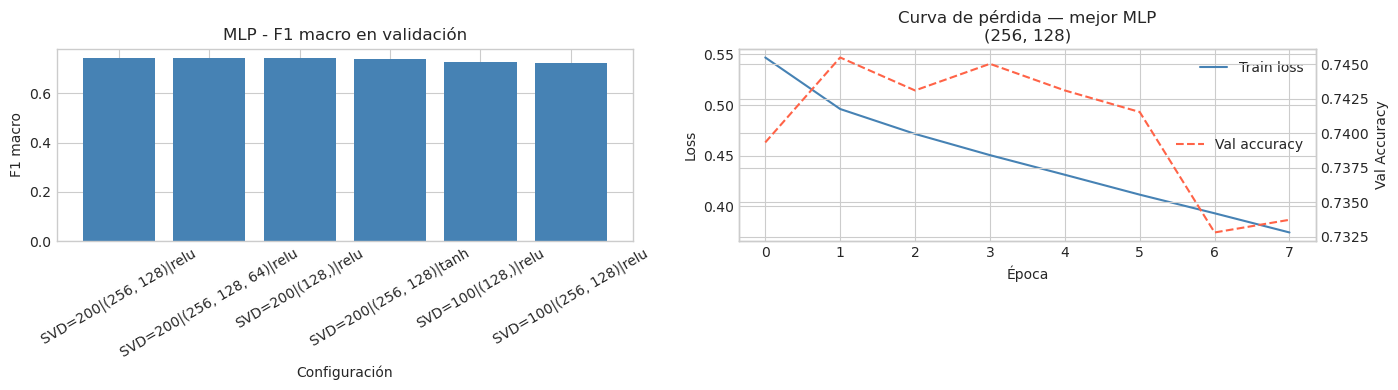

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_df = df_mlp.copy()
plot_df['config'] = [
    f"SVD={r.n_components}|{r.hidden_layer_sizes}|{r.activation}"
    for r in plot_df.itertuples()
]
axes[0].bar(plot_df['config'], plot_df['f1_macro'], color='steelblue')
axes[0].set_title('MLP - F1 macro en validación')
axes[0].set_xlabel('Configuración')
axes[0].set_ylabel('F1 macro')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(best_mlp.loss_curve_, label='Train loss', color='steelblue')
if hasattr(best_mlp, 'validation_scores_'):
    ax2 = axes[1].twinx()
    ax2.plot(best_mlp.validation_scores_, label='Val accuracy', color='tomato', linestyle='--')
    ax2.set_ylabel('Val Accuracy')
    ax2.legend(loc='center right')
axes[1].set_title(f'Curva de pérdida — mejor MLP\n{best_params["hidden_layer_sizes"]}')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


## 5. Entrenamiento final

Se reentrena el mejor pipeline usando la union de la muestra de train y validacion.

In [7]:
X_train_final = X_train_tfidf
y_train_final = np.asarray(y_train)
k_best        = best_params['n_components']

print(f"⏳ [1/3] SVD final ({k_best} comps) sobre {X_train_final.shape}...")
t0 = time.time()
svd_final = TruncatedSVD(n_components=k_best, algorithm='randomized', n_iter=2, random_state=SEED)
X_train_svd = svd_final.fit_transform(X_train_final)
print(f"   ✅ SVD listo en {time.time() - t0:.1f}s")

print(f"⏳ [2/3] StandardScaler final...")
t1 = time.time()
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_svd)
print(f"   ✅ Scaler listo en {time.time() - t1:.1f}s")

print(f"⏳ [3/3] Entrenando MLP final...")
t2 = time.time()
mlp_final = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    alpha=best_params['alpha'],
    solver='adam',
    batch_size=512,
    learning_rate='adaptive',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.05,
    n_iter_no_change=5,
    random_state=SEED,
    verbose=True,
)
mlp_final.fit(X_train_scaled_final, y_train_final)
print(f"   ✅ MLP final listo en {time.time() - t2:.1f}s | épocas: {mlp_final.n_iter_}")

model_final = Pipeline([
    ('svd',    svd_final),
    ('scaler', scaler_final),
    ('mlp',    mlp_final),
])
print(f'\n✅ Modelo final entrenado sobre {X_train_final.shape[0]:,} filas.')


⏳ [1/3] SVD final (200 comps) sobre (1360000, 100000)...
   ✅ SVD listo en 60.6s
⏳ [2/3] StandardScaler final...
   ✅ Scaler listo en 2.1s
⏳ [3/3] Entrenando MLP final...
Iteration 1, loss = 0.50041984
Validation score: 0.762603
Iteration 2, loss = 0.47699040
Validation score: 0.765279
Iteration 3, loss = 0.46883399
Validation score: 0.769809
Iteration 4, loss = 0.46245315
Validation score: 0.769559
Iteration 5, loss = 0.45731810
Validation score: 0.770338
Iteration 6, loss = 0.45292486
Validation score: 0.769471
Iteration 7, loss = 0.44912690
Validation score: 0.770838
Iteration 8, loss = 0.44553162
Validation score: 0.770000
Iteration 9, loss = 0.44220295
Validation score: 0.769485
Iteration 10, loss = 0.43925601
Validation score: 0.770265
Iteration 11, loss = 0.43657821
Validation score: 0.769103
Iteration 12, loss = 0.43427677
Validation score: 0.768176
Iteration 13, loss = 0.43179840
Validation score: 0.769559
Validation score did not improve more than tol=0.000100 for 5 consecuti

## 6. Evaluacion final en test

In [8]:
y_pred  = model_final.predict(X_test_tfidf)
y_proba = model_final.predict_proba(X_test_tfidf)[:, 1]

acc       = accuracy_score(y_test,  y_pred)
f1        = f1_score(y_test,        y_pred, average='macro')
auc       = roc_auc_score(y_test,   y_proba)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test,    y_pred, average='macro')

print('Métricas en test:')
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1 macro  : {f1:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  ROC AUC   : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, digits=4))


Métricas en test:
  Accuracy  : 0.7709
  F1 macro  : 0.7709
  Precision : 0.7709
  Recall    : 0.7709
  ROC AUC   : 0.8549

              precision    recall  f1-score   support

           0     0.7729    0.7679    0.7704    120129
           1     0.7689    0.7739    0.7714    119871

    accuracy                         0.7709    240000
   macro avg     0.7709    0.7709    0.7709    240000
weighted avg     0.7709    0.7709    0.7709    240000



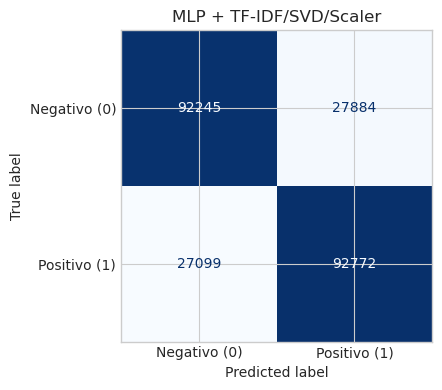

In [9]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negativo (0)', 'Positivo (1)']
)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('MLP + TF-IDF/SVD/Scaler')
plt.tight_layout()
plt.show()


## 7. Guardar modelo y resultados

In [10]:
joblib.dump(model_final, 'mlp_tfidf_svd_model.pkl')

results_final = pd.DataFrame([{
    'modelo':             'MLPClassifier',
    'encoding':           'TF-IDF + TruncatedSVD + StandardScaler',
    'member':             MEMBER,
    'final_train_size':   len(y_train_final),
    'n_components':       best_params['n_components'],
    'hidden_layer_sizes': str(best_params['hidden_layer_sizes']),
    'activation':         best_params['activation'],
    'alpha':              best_params['alpha'],
    'epocas_finales':     mlp_final.n_iter_,
    'accuracy':           round(acc,       4),
    'f1_macro':           round(f1,        4),
    'precision_macro':    round(precision, 4),
    'recall_macro':       round(recall,    4),
    'roc_auc':            round(auc,       4),
}])

results_final.to_csv('results_mlp_tfidf_svd.csv', index=False)
print('Archivos guardados:')
print('  mlp_tfidf_svd_model.pkl   → pipeline SVD + Scaler + MLP')
print('  results_mlp_tfidf_svd.csv → tabla de métricas')
print()
print(results_final.to_string(index=False))


Archivos guardados:
  mlp_tfidf_svd_model.pkl   → pipeline SVD + Scaler + MLP
  results_mlp_tfidf_svd.csv → tabla de métricas

       modelo                               encoding      member  final_train_size  n_components hidden_layer_sizes activation  alpha  epocas_finales  accuracy  f1_macro  precision_macro  recall_macro  roc_auc
MLPClassifier TF-IDF + TruncatedSVD + StandardScaler Alan Osorio           1360000           200         (256, 128)       relu 0.0001              13    0.7709    0.7709           0.7709        0.7709   0.8549


## 8. Registro en MLflow

2026/03/09 21:51:37 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:43 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:43 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:43 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:43 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:43 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:44 WARNING mlflow.tracking.request_header.regis

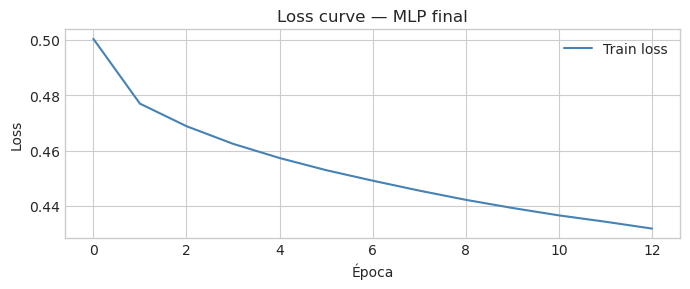

2026/03/09 21:55:46 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:46 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:46 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 21:55:46 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:46 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 21:55:46 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolvin

 Run ID   : 9dc8c31bdb8748a78da7b8aade4cabba
 Test F1  : 0.7709
 Test AUC : 0.8549
🏃 View run MLP_TFIDF-SVD_Alan Osorio at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1/runs/9dc8c31bdb8748a78da7b8aade4cabba
🧪 View experiment at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1


In [11]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('Parcial_1_NLP')

with mlflow.start_run(run_name=f'MLP_TFIDF-SVD_{MEMBER}') as run:
    mlflow.set_tags({
        'user': 'Alan Osorio', 'member': MEMBER,
        'model_type': 'MLPClassifier',
        'encoding': 'TF-IDF + TruncatedSVD + StandardScaler',
        'dataset': 'Sentiment140Twitter',
    })
    mlflow.log_params({
        'prep_remove_urls': True, 'prep_remove_mentions': True,
        'prep_remove_hashtags': True, 'prep_remove_emojis': True,
        'prep_remove_stopwords': False, 'prep_lemmatization': False,
    })
    mlflow.log_params({
        'vec_type': 'TfidfVectorizer', 'vec_max_features': 50000,
        'vec_min_df': 5, 'vec_max_df': 0.95,
        'vec_ngram_range': '(1,1)', 'vec_sublinear_tf': False, 'vec_norm': 'None',
    })
    mlflow.log_params({
        'model': 'MLPClassifier', 'dim_reduction': 'TruncatedSVD',
        'n_components': best_params['n_components'],
        'hidden_layer_sizes': str(best_params['hidden_layer_sizes']),
        'activation': best_params['activation'], 'alpha': best_params['alpha'],
        'solver': 'adam', 'batch_size': 512, 'max_iter': 50,
        'early_stopping': True, 'epocas_finales': mlp_final.n_iter_,
        'tune_sample_size': len(y_tr_tune),
        'final_train_size': len(y_train_final),
        'test_size': X_test_tfidf.shape[0], 'vocab_size': X_train_tfidf.shape[1],
        'seed': SEED,
    })

    # Train — solo 50k para evitar OOM
    y_pred_train  = model_final.predict(X_train_final[:50_000])
    y_proba_train = model_final.predict_proba(X_train_final[:50_000])[:, 1]
    mlflow.log_metrics({
        'train_accuracy':  round(accuracy_score(y_train_final[:50_000],  y_pred_train),                  4),
        'train_f1_macro':  round(f1_score(y_train_final[:50_000],        y_pred_train, average='macro'), 4),
        'train_precision': round(precision_score(y_train_final[:50_000], y_pred_train, average='macro'), 4),
        'train_recall':    round(recall_score(y_train_final[:50_000],    y_pred_train, average='macro'), 4),
        'train_roc_auc':   round(roc_auc_score(y_train_final[:50_000],   y_proba_train),                 4),
    })

    # Validacion
    k_val        = best_params['n_components']
    X_val_k_best = X_val_scaled[:, :k_val]
    y_pred_val   = best_mlp.predict(X_val_k_best)
    y_proba_val  = best_mlp.predict_proba(X_val_k_best)[:, 1]
    mlflow.log_metrics({
        'val_accuracy':  round(accuracy_score(y_val_arr,  y_pred_val),                  4),
        'val_f1_macro':  round(f1_score(y_val_arr,        y_pred_val, average='macro'), 4),
        'val_precision': round(precision_score(y_val_arr, y_pred_val, average='macro'), 4),
        'val_recall':    round(recall_score(y_val_arr,    y_pred_val, average='macro'), 4),
        'val_roc_auc':   round(roc_auc_score(y_val_arr,   y_proba_val),                 4),
    })

    # Test
    mlflow.log_metrics({
        'test_accuracy':  round(acc, 4), 'test_f1_macro':  round(f1, 4),
        'test_precision': round(precision, 4), 'test_recall': round(recall, 4),
        'test_roc_auc':   round(auc, 4),
    })

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(mlp_final.loss_curve_, color='steelblue', label='Train loss')
    ax.set_title('Loss curve — MLP final')
    ax.set_xlabel('Época'); ax.set_ylabel('Loss'); ax.legend()
    plt.tight_layout()
    fig.savefig('mlp_loss_curve.png', dpi=100)
    plt.show()
    mlflow.log_artifact('mlp_loss_curve.png')
    mlflow.log_artifact('results_mlp_tfidf_svd.csv')
    mlflow.sklearn.log_model(
        model_final, artifact_path='model',
        registered_model_name=f'MLP_TFIDF_SVD_{MEMBER}'
    )

    print('=' * 55)
    print(f' Run ID   : {run.info.run_id}')
    print(f' Test F1  : {f1:.4f}')
    print(f' Test AUC : {auc:.4f}')
    print('=' * 55)
